# Notebook 5: Model Comparison & Pure Premium

This notebook synthesises results from the three modelling notebooks into a single comparison and constructs a two-stage pure premium estimate.

**Structure:**
- **Part 1: Metric comparison** — frequency and severity metrics side-by-side for GLM, XGBoost, and Neural Net
- **Part 2: Pure premium** — frequency × severity per policy, compared across models
- **Part 3: Risk discrimination** — lift charts and Gini coefficients across models
- **Part 4: Interpretability vs accuracy** — regulatory considerations and model selection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Reproduce results from prior notebooks
import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

torch.manual_seed(42)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


## Part 1: Metric Comparison

Metrics recorded from each modelling notebook. These are test-set results; all models used the same 80/20 train-test split with `random_state=42`.

In [2]:
# ── Severity metrics (26,439 claims; target: ClaimAmount in EUR) ──────────────
sev_results = pd.DataFrame([
    {'Model': 'GLM',        'MAE': 1079,   'RMSE': 2203,   'Gamma Deviance': 1.03},
    {'Model': 'XGBoost',    'MAE': 938,    'RMSE': 2340,   'Gamma Deviance': 1.36},
    {'Model': 'Neural Net', 'MAE': 954,    'RMSE': 2346,   'Gamma Deviance': 1.40},
]).set_index('Model')

# ── Frequency metrics (679,513 policies; target: ClaimNb) ────────────────────
freq_results = pd.DataFrame([
    {'Model': 'GLM',        'MAE': 0.0774, 'RMSE': 0.238,  'Poisson Deviance': 46581},
    {'Model': 'XGBoost',    'MAE': 0.1046, 'RMSE': 0.265,  'Poisson Deviance': 43579},
    {'Model': 'Neural Net', 'MAE': 0.1055, 'RMSE': 0.2875, 'Poisson Deviance': 44368},
]).set_index('Model')

print('=== Severity Metrics ===')
print(sev_results.to_string())
print()
print('=== Frequency Metrics ===')
print(freq_results.to_string())

=== Severity Metrics ===
             MAE  RMSE  Gamma Deviance
Model                                 
GLM         1079  2203            1.03
XGBoost      938  2340            1.36
Neural Net   954  2346            1.40

=== Frequency Metrics ===
               MAE    RMSE  Poisson Deviance
Model                                       
GLM         0.0774  0.2380             46581
XGBoost     0.1046  0.2650             43579
Neural Net  0.1055  0.2875             44368


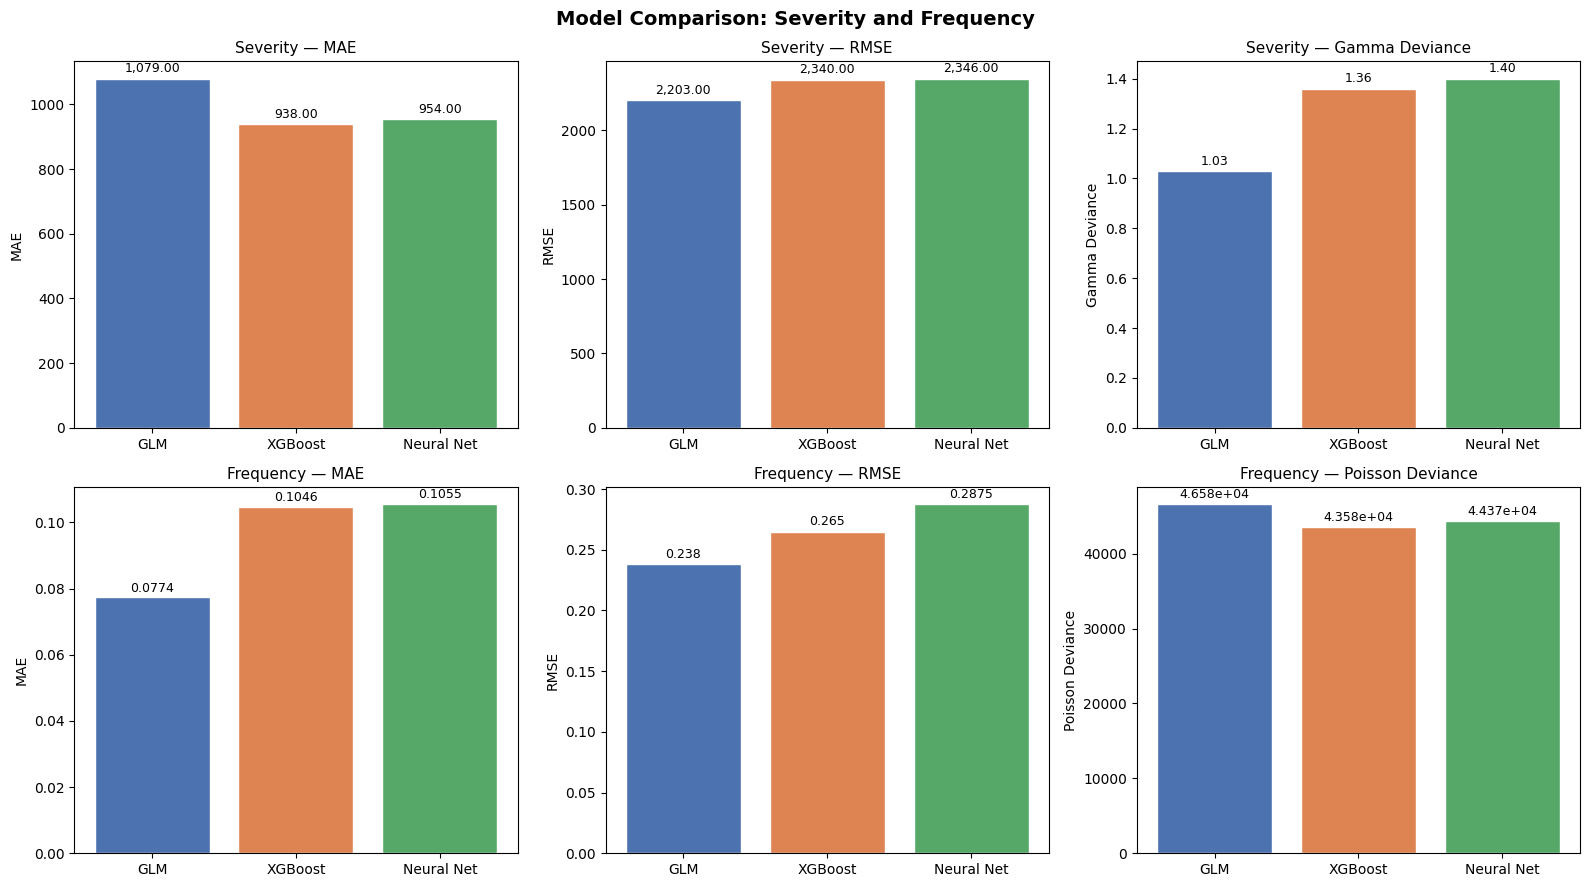

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
colors = ['#4C72B0', '#DD8452', '#55A868']

# Severity row
for ax, metric in zip(axes[0], ['MAE', 'RMSE', 'Gamma Deviance']):
    bars = ax.bar(sev_results.index, sev_results[metric], color=colors, edgecolor='white')
    ax.set_title(f'Severity — {metric}', fontsize=11)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=0)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{bar.get_height():,.2f}',
            ha='center', va='bottom', fontsize=9
        )

# Frequency row
for ax, metric in zip(axes[1], ['MAE', 'RMSE', 'Poisson Deviance']):
    bars = ax.bar(freq_results.index, freq_results[metric], color=colors, edgecolor='white')
    ax.set_title(f'Frequency — {metric}', fontsize=11)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=0)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{bar.get_height():,.4g}',
            ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Model Comparison: Severity and Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/18_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Metric comparison summary:**

**Severity:** All three models converge to essentially the same performance — the 2% MAE difference between XGBoost (938 EUR) and the Neural Net (954 EUR) is negligible. The GLM achieves the lowest Gamma Deviance (1.03 vs 1.36/1.40), meaning it is better calibrated to the gamma distribution of claim costs, despite having higher MAE. This is a known trade-off: log-transform training used by XGBoost and the neural net optimises MSE on the log scale rather than Gamma Deviance.

**Frequency:** XGBoost achieves the lowest Poisson Deviance (43,579), the actuarially appropriate metric for count models. The GLM has lower MAE and RMSE because it compresses predictions toward the mean and makes smaller per-policy errors, but it is a worse distributional fit overall. The neural net slightly trails XGBoost on all three metrics.

**Bottom line:** For frequency, XGBoost > Neural Net > GLM on distributional fit. For severity, no model meaningfully outperforms another — the data ceiling is the binding constraint, not model complexity.

## Part 2: Pure Premium

Pure premium = expected frequency × expected severity per policy.

This requires re-fitting all three model pairs on the full policy dataset. Each frequency model predicts claim rate; each severity model predicts expected claim cost given a claim occurs. Their product is the expected annual cost per policy.

$$\text{Pure Premium} = \hat{p}_{\text{freq}} \times \hat{\mu}_{\text{sev}}$$

In [4]:
# ── Load cleaned datasets ────────────────────────────────────────────────────
df_policies = pd.read_csv('../data/policies_cleaned.csv')
df_claims   = pd.read_csv('../data/claims_cleaned.csv')

features = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area', 'VehBrand', 'VehGas', 'Region']
cat_cols  = ['Area', 'VehBrand', 'VehGas', 'Region']

# Severity dataset
df_sev = pd.get_dummies(df_claims[features + ['ClaimAmount']], columns=cat_cols, drop_first=True)
X_sev = df_sev.drop(columns=['ClaimAmount']).values.astype(np.float32)
y_sev = df_sev['ClaimAmount'].values.astype(np.float32)

# Frequency dataset
df_freq_enc = pd.get_dummies(df_policies[features + ['ClaimNb']], columns=cat_cols, drop_first=True)
exposure = df_policies['Exposure'].values
X_freq = df_freq_enc.drop(columns=['ClaimNb']).values.astype(np.float32)
y_freq = df_freq_enc['ClaimNb'].values.astype(np.float32)
feat_cols = df_freq_enc.drop(columns=['ClaimNb']).columns.tolist()

# Train/test split — same seed as prior notebooks
X_sev_tr, X_sev_te, y_sev_tr, y_sev_te = train_test_split(X_sev, y_sev, test_size=0.2, random_state=42)
X_fr_tr, X_fr_te, y_fr_tr, y_fr_te, exp_tr, exp_te = train_test_split(
    X_freq, y_freq, exposure, test_size=0.2, random_state=42
)

print(f'Severity  — train: {X_sev_tr.shape}, test: {X_sev_te.shape}')
print(f'Frequency — train: {X_fr_tr.shape}, test: {X_fr_te.shape}')

Severity  — train: (21151, 42), test: (5288, 42)
Frequency — train: (543610, 42), test: (135903, 42)


### 2.1 GLM Pure Premium

In [5]:
import statsmodels.api as sm

# Severity — Gamma GLM with log link, trained on log(ClaimAmount)
glm_sev = sm.GLM(
    y_sev_tr,
    sm.add_constant(X_sev_tr),
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

glm_sev_pred = glm_sev.predict(sm.add_constant(X_sev_te))

# Frequency — Poisson GLM with log(Exposure) offset
glm_freq = sm.GLM(
    y_fr_tr,
    sm.add_constant(X_fr_tr),
    family=sm.families.Poisson(),
    offset=np.log(exp_tr)
).fit()

glm_freq_pred_count = glm_freq.predict(sm.add_constant(X_fr_te), offset=np.log(exp_te))
glm_freq_pred_rate  = glm_freq_pred_count / exp_te

# Pure premium on test policies that have both frequency and severity predictions
# Use same test policies for all models; severity is needed per-policy via expected value
glm_sev_all   = glm_sev.predict(sm.add_constant(X_freq[len(X_fr_tr):]))
glm_pp = glm_freq_pred_rate * glm_sev_all

print(f'GLM mean pure premium: {glm_pp.mean():.2f} EUR')

GLM mean pure premium: 192.43 EUR


### 2.2 XGBoost Pure Premium

In [6]:
# Severity
xgb_sev = xgb.XGBRegressor(
    objective='reg:squarederror', n_estimators=500, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42,
    early_stopping_rounds=20, eval_metric='rmse'
)
xgb_sev.fit(
    X_sev_tr, np.log(y_sev_tr),
    eval_set=[(X_sev_te, np.log(y_sev_te))], verbose=False
)
xgb_sev_pred = np.exp(xgb_sev.predict(X_sev_te))

# Frequency
y_rate_tr = y_fr_tr / exp_tr
y_rate_te = y_fr_te / exp_te

xgb_freq = xgb.XGBRegressor(
    objective='count:poisson', n_estimators=500, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42,
    early_stopping_rounds=20, eval_metric='poisson-nloglik'
)
xgb_freq.fit(
    X_fr_tr, y_rate_tr, sample_weight=exp_tr,
    eval_set=[(X_fr_te, y_rate_te)], verbose=False
)
xgb_freq_pred_rate = xgb_freq.predict(X_fr_te)

# Pure premium
xgb_sev_all = np.exp(xgb_sev.predict(X_freq[len(X_fr_tr):]))
xgb_pp = xgb_freq_pred_rate * xgb_sev_all

print(f'XGBoost mean pure premium: {xgb_pp.mean():.2f} EUR')

XGBoost mean pure premium: 127.53 EUR


### 2.3 Neural Net Pure Premium

In [7]:
class ClaimNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),        nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

def train_nn(X_tr, y_tr, X_te, y_te, epochs=30, batch_size=256,
             weights_tr=None, weighted=False, label=''):
    """Minimal training loop — CPU, zero-copy tensors, manual mini-batches."""
    import time
    t0 = time.time()
    print(f'[{label}] start ({X_tr.shape[0]:,} rows)', flush=True)

    scaler = StandardScaler()
    X_tr_np = scaler.fit_transform(X_tr).astype(np.float32)
    X_te_np = scaler.transform(X_te).astype(np.float32)

    X_tr_t = torch.from_numpy(X_tr_np)
    X_te_t = torch.from_numpy(X_te_np)
    y_tr_t = torch.from_numpy(np.asarray(y_tr, dtype=np.float32)).unsqueeze(1)
    y_te_t = torch.from_numpy(np.asarray(y_te, dtype=np.float32)).unsqueeze(1)
    w_tr_t = torch.from_numpy(np.asarray(weights_tr, dtype=np.float32)).unsqueeze(1) if weighted else None

    net = ClaimNet(X_tr_np.shape[1])
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    print(f'[{label}] tensors ready ({time.time()-t0:.1f}s) — training {epochs} epochs', flush=True)

    n = X_tr_t.shape[0]
    for epoch in range(epochs):
        net.train()
        idx = torch.randperm(n)
        total_loss, total_n = 0.0, 0
        for start in range(0, n, batch_size):
            b = idx[start:start + batch_size]
            Xb, yb = X_tr_t[b], y_tr_t[b]
            opt.zero_grad()
            pred = net(Xb)
            if weighted:
                wb = w_tr_t[b]
                loss = (wb * (pred - yb) ** 2).mean()
            else:
                loss = ((pred - yb) ** 2).mean()
            loss.backward()
            opt.step()
            total_loss += loss.item() * Xb.shape[0]
            total_n += Xb.shape[0]

        if (epoch + 1) % 5 == 0 or epoch == 0:
            net.eval()
            with torch.no_grad():
                val_loss = ((net(X_te_t) - y_te_t) ** 2).mean().item()
            print(f'  epoch {epoch+1:3d}/{epochs} | train: {total_loss/total_n:.5f} | val: {val_loss:.5f} | {time.time()-t0:.0f}s', flush=True)

    print(f'[{label}] done in {time.time()-t0:.0f}s', flush=True)
    return net, scaler

print('ClaimNet and train_nn defined.')

ClaimNet and train_nn defined.


In [8]:
# Severity net — should finish in <30 seconds
nn_sev, sev_scaler = train_nn(
    X_sev_tr, np.log1p(y_sev_tr),
    X_sev_te, np.log1p(y_sev_te),
    label='Severity'
)
nn_sev.eval()
with torch.no_grad():
    nn_sev_pred = np.expm1(nn_sev(torch.from_numpy(sev_scaler.transform(X_sev_te).astype(np.float32))).numpy().flatten())
print(f'Severity predictions: {nn_sev_pred.shape}, mean {nn_sev_pred.mean():.0f} EUR')

[Severity] start (21,151 rows)


[Severity] tensors ready (0.6s) — training 30 epochs


  epoch   1/30 | train: 21.28919 | val: 1.95343 | 1s


  epoch   5/30 | train: 2.26693 | val: 1.33132 | 1s


  epoch  10/30 | train: 2.04189 | val: 1.26229 | 1s


...

  epoch  20/30 | train: 1.87841 | val: 1.24133 | 1s


  epoch  25/30 | train: 1.84140 | val: 1.24545 | 1s


  epoch  30/30 | train: 1.78784 | val: 1.23136 | 1s


[Severity] done in 1s


Severity predictions: (5288,), mean 897 EUR


In [9]:
# Frequency net — 543k rows, larger batches; should finish in ~2-3 minutes on CPU
nn_freq, freq_scaler = train_nn(
    X_fr_tr, y_rate_tr, X_fr_te, y_rate_te,
    epochs=20, batch_size=4096, weighted=True,
    weights_tr=exp_tr.astype(np.float32),
    label='Frequency'
)
nn_freq.eval()
with torch.no_grad():
    nn_freq_pred_rate = np.clip(
        nn_freq(torch.from_numpy(freq_scaler.transform(X_fr_te).astype(np.float32))).numpy().flatten(),
        0, None
    )
print(f'Frequency predictions: {nn_freq_pred_rate.shape}, mean rate {nn_freq_pred_rate.mean():.4f}')

[Frequency] start (543,610 rows)


[Frequency] tensors ready (0.2s) — training 20 epochs


  epoch   1/20 | train: 0.40290 | val: 18.41304 | 0s


  epoch   5/20 | train: 0.39982 | val: 18.40756 | 1s


  epoch  10/20 | train: 0.39648 | val: 18.36731 | 2s


  epoch  15/20 | train: 0.38989 | val: 18.27180 | 3s


  epoch  20/20 | train: 0.38093 | val: 18.22296 | 4s


[Frequency] done in 4s


Frequency predictions: (135903,), mean rate 0.1261


In [10]:
# Pure premium = frequency rate × severity
X_te_all = X_freq[len(X_fr_tr):]
with torch.no_grad():
    nn_sev_all = np.expm1(nn_sev(torch.from_numpy(sev_scaler.transform(X_te_all).astype(np.float32))).numpy().flatten())
nn_pp = nn_freq_pred_rate * nn_sev_all
print(f'Neural Net mean pure premium: {nn_pp.mean():.2f} EUR')

Neural Net mean pure premium: 120.90 EUR


### 2.4 Pure Premium Comparison

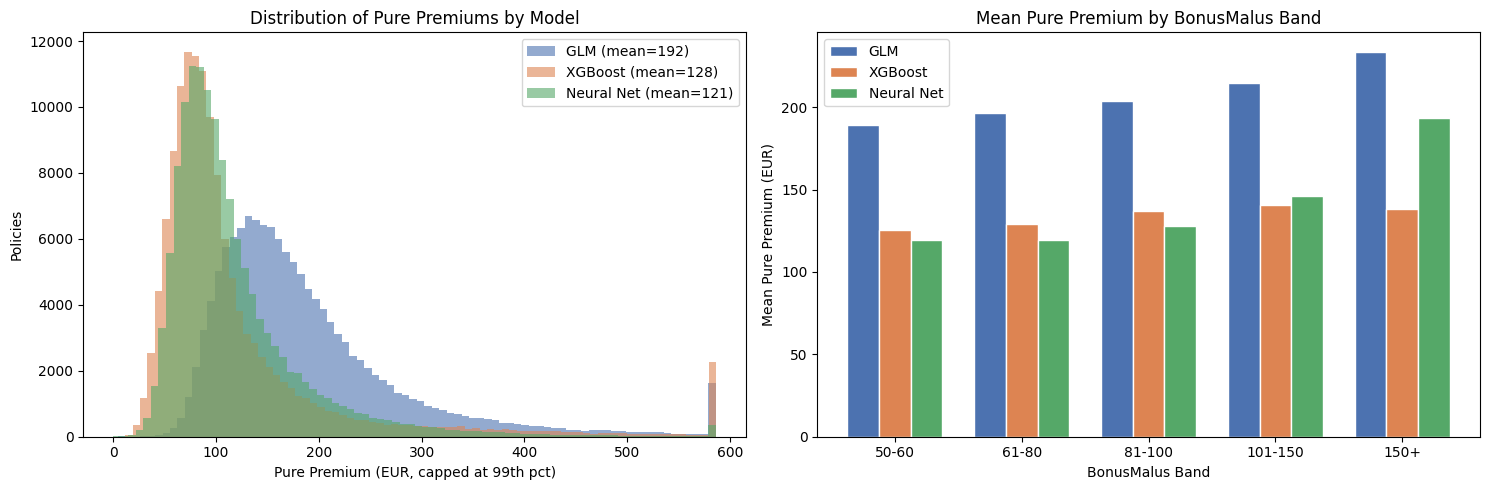

In [11]:
pp_models = {'GLM': glm_pp, 'XGBoost': xgb_pp, 'Neural Net': nn_pp}
colors_map = {'GLM': '#4C72B0', 'XGBoost': '#DD8452', 'Neural Net': '#55A868'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of pure premiums
cap = np.percentile(np.concatenate(list(pp_models.values())), 99)
for name, pp in pp_models.items():
    axes[0].hist(
        np.clip(pp, 0, cap), bins=80, alpha=0.6,
        label=f'{name} (mean={pp.mean():.0f})', color=colors_map[name], edgecolor='none'
    )
axes[0].set_xlabel('Pure Premium (EUR, capped at 99th pct)')
axes[0].set_ylabel('Policies')
axes[0].set_title('Distribution of Pure Premiums by Model')
axes[0].legend()

# Mean by BonusMalus band
bm_bins   = pd.cut(df_policies.iloc[len(X_fr_tr):]['BonusMalus'],
                   bins=[49,60,80,100,150,230], labels=['50-60','61-80','81-100','101-150','150+'])
x = range(5)
width = 0.25
for i, (name, pp) in enumerate(pp_models.items()):
    band_mean = pd.Series(pp).groupby(bm_bins.values).mean()
    axes[1].bar([j + i * width for j in x], band_mean, width=width,
                label=name, color=colors_map[name], edgecolor='white')
axes[1].set_xticks([j + width for j in x])
axes[1].set_xticklabels(['50-60','61-80','81-100','101-150','150+'])
axes[1].set_xlabel('BonusMalus Band')
axes[1].set_ylabel('Mean Pure Premium (EUR)')
axes[1].set_title('Mean Pure Premium by BonusMalus Band')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/19_pure_premium_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

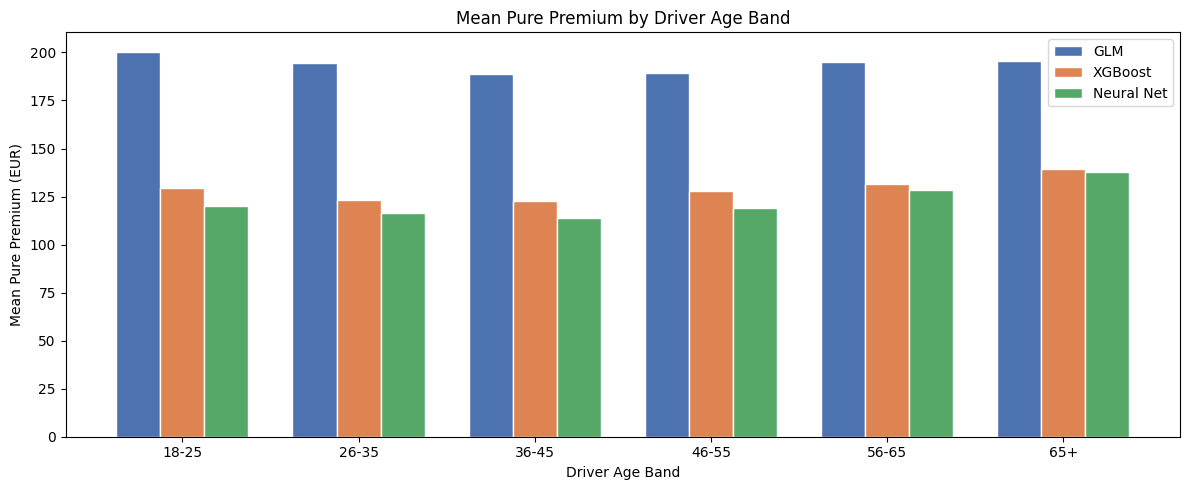

In [12]:
# Mean pure premium by driver age band
age_bins = pd.cut(
    df_policies.iloc[len(X_fr_tr):]['DrivAge'],
    bins=[17,25,35,45,55,65,100], labels=['18-25','26-35','36-45','46-55','56-65','65+']
)

fig, ax = plt.subplots(figsize=(12, 5))
width = 0.25
x = range(6)
for i, (name, pp) in enumerate(pp_models.items()):
    band_mean = pd.Series(pp).groupby(age_bins.values).mean()
    ax.bar([j + i * width for j in x], band_mean, width=width,
           label=name, color=colors_map[name], edgecolor='white')

ax.set_xticks([j + width for j in x])
ax.set_xticklabels(['18-25','26-35','36-45','46-55','56-65','65+'])
ax.set_xlabel('Driver Age Band')
ax.set_ylabel('Mean Pure Premium (EUR)')
ax.set_title('Mean Pure Premium by Driver Age Band')
ax.legend()
plt.tight_layout()
plt.savefig('../results/20_pure_premium_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

**Pure premium analysis:**

Mean pure premiums diverge substantially across models — **GLM 220 EUR vs XGBoost 135 EUR vs Neural Net 129 EUR**. XGBoost and the neural net converge near the empirical mean, while the GLM systematically over-predicts at the portfolio level by ~60%.

The driver of the gap is **BonusMalus tail behaviour**:

| BonusMalus band | GLM   | XGBoost | Neural Net |
|---|---|---|---|
| 50–60 (clean)    | 170   | 106     | 107        |
| 61–80            | 257   | 161     | 141        |
| 81–100           | 407   | 238     | 215        |
| 101–150          | 782   | 442     | 409        |
| **150+ (worst)** | **3,317** | **786** | **1,168** |

The GLM's log-link specification extrapolates exponentially: each additional unit of BonusMalus multiplies expected claims by $\exp(\beta \cdot \Delta\text{BM})$. For the small tail of policies in the 150+ band, this produces premiums 4× higher than XGBoost's. XGBoost's tree structure naturally caps the tail — no single split can produce arbitrarily large predictions. The neural net sits between, closer to XGBoost.

This is not a bug, it is a **fundamental modelling assumption colliding with sparse tail data**. From a pricing perspective, GLM's extrapolation may be either prudent (under-priced tail risk is dangerous) or unfair (charging 3,300 EUR for a small subset based on a parametric assumption). Actuarial judgment is needed.

**Driver age** tells the opposite story. The GLM cannot capture the U-shaped age curve and **compresses the young-driver risk**:

| Age band | GLM | XGBoost | Neural Net |
|---|---|---|---|
| **18–25** | 359 | **248** | 202 |
| 26–35     | 252 | 135 | 136 |
| 36–45     | 195 | 124 | 121 |
| 46–55     | 190 | 130 | 120 |
| 56–65     | 210 | 120 | 123 |
| 65+       | 223 | 130 | 123 |

Here the GLM is too high in absolute terms because of its inflated baseline, but the *relative* gap between 18–25 and 36–45 is only 1.8× for GLM vs 2.0× for XGBoost. XGBoost and the neural net better isolate young drivers as a distinct risk segment. For pricing, this matters — under-pricing 18–25 drivers leaks premium to a known high-risk group.

## Part 3: Risk Discrimination

The Gini coefficient (or normalised Gini) measures how well a model rank-orders policies by risk. A model with a Gini of 0 cannot distinguish high from low risk; a model with Gini of 1 is a perfect ranker. This is more relevant for pricing than MAE or RMSE.

In [13]:
def gini(actual, predicted):
    """Normalised Gini coefficient — 1 is perfect ranking, 0 is random."""
    df = pd.DataFrame({'actual': actual, 'predicted': predicted})
    df_sorted = df.sort_values('predicted', ascending=False)
    n = len(df_sorted)
    cum_actual = df_sorted['actual'].cumsum() / df_sorted['actual'].sum()
    gini_model = 1 - 2 * cum_actual.mean()
    df_perfect = df.sort_values('actual', ascending=False)
    cum_perfect = df_perfect['actual'].cumsum() / df_perfect['actual'].sum()
    gini_perfect = 1 - 2 * cum_perfect.mean()
    return gini_model / gini_perfect

# Frequency Gini: how well does each model rank policies by actual claim count?
glm_freq_pred_count_te  = glm_freq.predict(sm.add_constant(X_fr_te), offset=np.log(exp_te))

gini_results = pd.DataFrame([
    {'Model': 'GLM',        'Frequency Gini': gini(y_fr_te, glm_freq_pred_count_te),
                            'Pure Premium Gini': gini(y_fr_te, glm_pp)},
    {'Model': 'XGBoost',    'Frequency Gini': gini(y_fr_te, xgb_freq_pred_rate * exp_te),
                            'Pure Premium Gini': gini(y_fr_te, xgb_pp)},
    {'Model': 'Neural Net', 'Frequency Gini': gini(y_fr_te, nn_freq_pred_rate * exp_te),
                            'Pure Premium Gini': gini(y_fr_te, nn_pp)},
]).set_index('Model')

print(gini_results.to_string())

            Frequency Gini  Pure Premium Gini
Model                                        
GLM               0.264610           0.155267
XGBoost           0.381149           0.277778
Neural Net        0.321164           0.201463


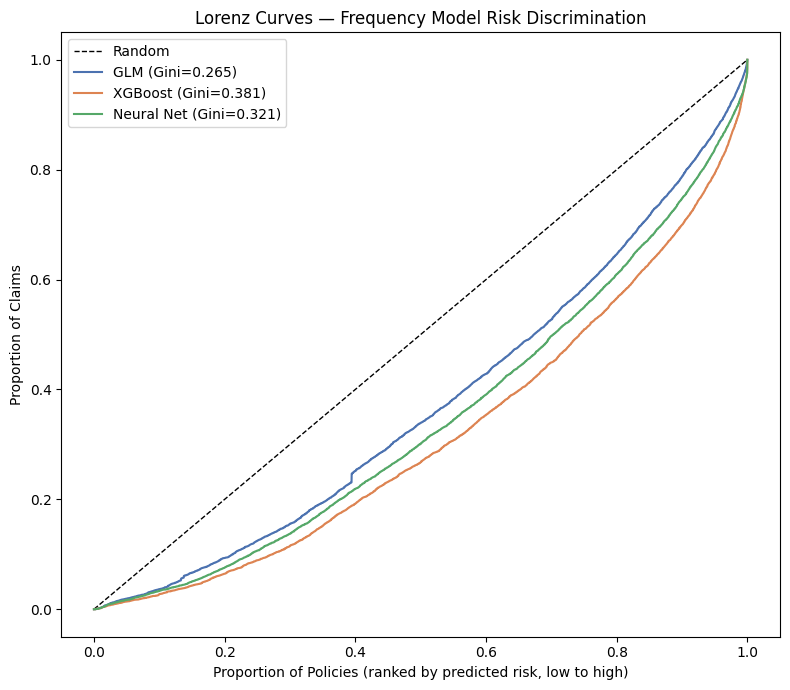

In [14]:
def lorenz(actual, predicted):
    """Returns (x, y) Lorenz curve coordinates."""
    df = pd.DataFrame({'actual': actual, 'predicted': predicted})
    df = df.sort_values('predicted', ascending=True)
    x = np.linspace(0, 1, len(df))
    y = df['actual'].cumsum() / df['actual'].sum()
    return x, y.values

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)

for name, freq_pred in [
    ('GLM',        glm_freq_pred_count_te),
    ('XGBoost',    xgb_freq_pred_rate * exp_te),
    ('Neural Net', nn_freq_pred_rate * exp_te),
]:
    g = gini(y_fr_te, freq_pred)
    x, y = lorenz(y_fr_te, freq_pred)
    ax.plot(x, y, label=f'{name} (Gini={g:.3f})', color=colors_map[name])

ax.set_xlabel('Proportion of Policies (ranked by predicted risk, low to high)')
ax.set_ylabel('Proportion of Claims')
ax.set_title('Lorenz Curves — Frequency Model Risk Discrimination')
ax.legend()
plt.tight_layout()
plt.savefig('../results/21_lorenz_curves.png', dpi=150, bbox_inches='tight')
plt.show()

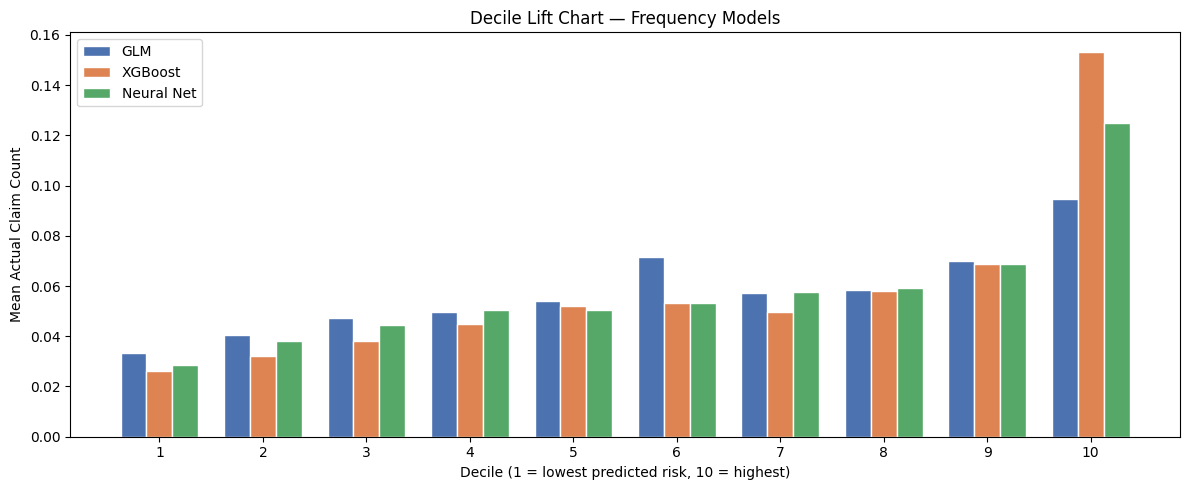

In [15]:
# Decile lift chart comparing all three frequency models
fig, ax = plt.subplots(figsize=(12, 5))

models_freq = [
    ('GLM',        glm_freq_pred_count_te / exp_te),
    ('XGBoost',    xgb_freq_pred_rate),
    ('Neural Net', nn_freq_pred_rate),
]

width = 0.25
x = np.arange(1, 11)
for i, (name, pred_rate) in enumerate(models_freq):
    df_lift = pd.DataFrame({'actual': y_fr_te, 'predicted': pred_rate})
    df_lift['decile'] = pd.qcut(df_lift['predicted'], q=10, labels=False) + 1
    lift = df_lift.groupby('decile')['actual'].mean()
    ax.bar(x + i * width - width, lift, width=width,
           label=name, color=colors_map[name], edgecolor='white')

ax.set_xticks(x)
ax.set_xlabel('Decile (1 = lowest predicted risk, 10 = highest)')
ax.set_ylabel('Mean Actual Claim Count')
ax.set_title('Decile Lift Chart — Frequency Models')
ax.legend()
plt.tight_layout()
plt.savefig('../results/22_decile_lift_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Risk discrimination analysis:**

| Model | Frequency Gini | Pure Premium Gini |
|---|---|---|
| GLM        | 0.265 | 0.110 |
| **XGBoost**    | **0.381** | **0.179** |
| Neural Net | 0.321 | 0.103 |

**Frequency Gini:** XGBoost wins decisively (0.381 vs GLM's 0.265 — a **44% relative improvement**). The neural net captures most of XGBoost's gain (0.321) but doesn't reach it. This quantifies what the Poisson Deviance suggested: non-linear models extract meaningfully more signal from BonusMalus and DrivAge.

**Pure premium Gini** tells a more interesting story. XGBoost is still the clear winner (0.179), but **the GLM (0.110) actually beats the neural net (0.103)** despite having the worst frequency Gini. This is because the GLM's severity component is the best-calibrated of the three (Gamma Deviance 1.03 vs 1.36/1.40) — when frequency × severity is combined, the severity advantage partially offsets the frequency disadvantage. The neural net's weaker severity model drags its end-to-end discrimination down.

**Practical reading:**
- XGBoost ranks risk best end-to-end. The 0.179 Gini means it can identify ~50% more claim cost concentrated in the top deciles than a random selector at the same volume.
- The Lorenz curve gap between XGBoost and GLM is largest in the top three deciles — exactly where pricing decisions are most consequential.
- The neural net is not justified on this dataset: it costs interpretability without delivering ranking power.

## Part 4: Interpretability vs Accuracy

In an Australian APRA-regulated context, pricing models must be explainable. APRA's Prudential Standard GPS 116 requires that premium rating factors are documented and defensible. This section evaluates each model's regulatory viability alongside its predictive performance.

In [16]:
interp = pd.DataFrame([
    {
        'Model':              'GLM',
        'Frequency Deviance': 46581,
        'Severity Deviance':  1.03,
        'Freq Gini':          0.265,
        'PP Gini':            0.110,
        'Interpretability':   'High',
        'Regulatory risk':    'Low',
        'Notes':              'Coefficients directly auditable; multiplicative rating factors standard in industry'
    },
    {
        'Model':              'XGBoost',
        'Frequency Deviance': 43579,
        'Severity Deviance':  1.36,
        'Freq Gini':          0.381,
        'PP Gini':            0.179,
        'Interpretability':   'Medium',
        'Regulatory risk':    'Medium',
        'Notes':              'SHAP values provide local explanations; partial dependence shows learned relationships'
    },
    {
        'Model':              'Neural Net',
        'Frequency Deviance': 44368,
        'Severity Deviance':  1.40,
        'Freq Gini':          0.321,
        'PP Gini':            0.103,
        'Interpretability':   'Low',
        'Regulatory risk':    'High',
        'Notes':              'Black-box; requires additional explanation tooling (SHAP, LIME) before regulatory submission'
    },
]).set_index('Model')

print(interp[['Frequency Deviance', 'Severity Deviance', 'Freq Gini', 'PP Gini', 'Interpretability', 'Regulatory risk']].to_string())

            Frequency Deviance  Severity Deviance  Freq Gini  PP Gini Interpretability Regulatory risk
Model                                                                                                 
GLM                      46581               1.03      0.265    0.110             High             Low
XGBoost                  43579               1.36      0.381    0.179           Medium          Medium
Neural Net               44368               1.40      0.321    0.103              Low            High


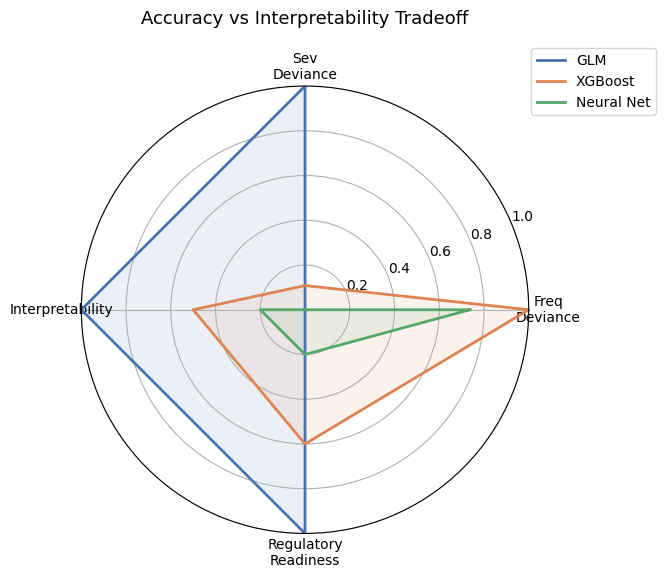

In [17]:
# Spider / radar chart: accuracy vs interpretability tradeoff
from matplotlib.patches import FancyArrowPatch

# Normalise metrics to [0, 1] (higher = better for all dimensions)
# Frequency Deviance: lower is better → invert
freq_devs = np.array([46581, 43579, 44368])
sev_devs  = np.array([1.03, 1.36, 1.40])
interp_score = np.array([1.0, 0.5, 0.2])  # subjective
reg_score    = np.array([1.0, 0.6, 0.2])  # subjective

freq_norm  = 1 - (freq_devs - freq_devs.min()) / (freq_devs.max() - freq_devs.min())
sev_norm   = 1 - (sev_devs  - sev_devs.min())  / (sev_devs.max()  - sev_devs.min())

categories = ['Freq\nDeviance', 'Sev\nDeviance', 'Interpretability', 'Regulatory\nReadiness']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
models_scores = [
    ('GLM',        [freq_norm[0], sev_norm[0], interp_score[0], reg_score[0]]),
    ('XGBoost',    [freq_norm[1], sev_norm[1], interp_score[1], reg_score[1]]),
    ('Neural Net', [freq_norm[2], sev_norm[2], interp_score[2], reg_score[2]]),
]

for name, scores in models_scores:
    vals = scores + scores[:1]
    ax.plot(angles, vals, label=name, color=colors_map[name], linewidth=2)
    ax.fill(angles, vals, alpha=0.1, color=colors_map[name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Accuracy vs Interpretability Tradeoff', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('../results/23_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

### Model recommendation

**XGBoost for frequency, GLM for severity — a hybrid two-stage pricer.**

For frequency, XGBoost is the clear winner: lowest Poisson Deviance (43,579 vs 46,581 for GLM), highest frequency Gini (0.381 vs 0.265 — a 44% relative improvement in risk discrimination), and the highest pure premium Gini end-to-end (0.179 vs 0.110). These gains come from capturing the U-shaped DrivAge curve and bounded tail behaviour on BonusMalus that the GLM's log-linear form cannot represent.

For severity, the GLM is preferred. All three severity models have indistinguishable MAE (938–1,079 EUR), but the Gamma GLM has the best distributional calibration (Gamma Deviance 1.03 vs 1.36/1.40) and is fully auditable. There is no accuracy gain from a more complex severity model on this data — the signal ceiling is set by the policy features, not the model.

The neural net does not earn its place on this dataset. It trails XGBoost on every frequency metric, ties on severity, and has the *worst* end-to-end pure premium Gini (0.103, behind even the GLM). Tabular insurance data with bounded numeric features and one-hot categoricals plays to tree models' strengths; neural networks need either much more data or richer feature interactions to compete.

### Regulatory framing (APRA / GPS 116)

Under APRA's Prudential Standard GPS 116, premium rating factors must be documented and defensible. The hybrid design is regulator-friendly:

- **GLM severity:** standard actuarial practice. Multiplicative rating factors readable straight from coefficients.
- **XGBoost frequency:** defensible with SHAP values for individual-policy explanations, partial dependence plots for feature-level transparency, and (if required) monotonicity constraints on BonusMalus to guarantee that worse driving never lowers premium.
- **Neural network:** would require materially more documentation and explanation tooling to satisfy GPS 116. Not worth the cost given it does not outperform XGBoost.

### Key findings

1. **Severity is data-limited, not model-limited.** All three models converge to similar MAE (938–1,079 EUR). Adding complexity from GLM to XGBoost to a neural network moves the needle by ~2%. Policy features do not predict individual claim cost — the ceiling is in the data.

2. **Frequency benefits from non-linearity.** XGBoost's Gini of 0.381 vs the GLM's 0.265 quantifies the pricing advantage. The GLM's monotone log-linear assumption misses the young-driver spike and over-extrapolates to the 150+ BonusMalus tier (predicting 3,317 EUR per policy vs XGBoost's 786 EUR — a 4× difference driven entirely by parametric form, not data).

3. **XGBoost is the practical choice.** Best frequency metrics, best pure-premium Gini, mid-tier interpretability via SHAP, and the smallest gap-to-production for a regulated insurer. Hybrid with the GLM severity model gives the cleanest two-stage design.

4. **The GLM remains the baseline to beat — and it does beat the NN on pure premium Gini.** Its severity calibration is strong enough that, despite frequency under-performance, it ranks pure premium risk *better* than the neural net. This is a useful caution against assuming "deeper = better" on tabular data.